# Title

### Imports

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Load music.csv

In [2]:
music = pd.read_csv("music.csv")

#### Head and Tail

In [24]:
print("HEAD:")
music.head()

HEAD:


,title,rank,date,artist,url,region,chart,trend,streams
0,Chantaje (feat. Maluma),1,2017-01-01,Shakira,https://open.spotify.com/track/6mICuAdrwEjh6Y6...,Argentina,top200,SAME_POSITION,253019.0
1,Vente Pa' Ca (feat. Maluma),2,2017-01-01,Ricky Martin,https://open.spotify.com/track/7DM4BPaS7uofFul...,Argentina,top200,MOVE_UP,223988.0
2,Reggaetón Lento (Bailemos),3,2017-01-01,CNCO,https://open.spotify.com/track/3AEZUABDXNtecAO...,Argentina,top200,MOVE_DOWN,210943.0
3,Safari,4,2017-01-01,"J Balvin, Pharrell Williams, BIA, Sky",https://open.spotify.com/track/6rQSrBHf7HlZjtc...,Argentina,top200,SAME_POSITION,173865.0
4,Shaky Shaky,5,2017-01-01,Daddy Yankee,https://open.spotify.com/track/58IL315gMSTD37D...,Argentina,top200,MOVE_UP,153956.0


In [25]:
print("TAIL:")
music.tail()


TAIL:


,title,rank,date,artist,url,region,chart,trend,streams
26173480,BYE,46,2021-07-31,Jaden,https://open.spotify.com/track/3OUyyDN7EZrL7i0...,Vietnam,viral50,MOVE_UP,9565.0
26173481,Pillars,47,2021-07-31,My Anh,https://open.spotify.com/track/6eky30oFiQbHUAT...,Vietnam,viral50,NEW_ENTRY,9565.0
26173482,Gái Độc Thân,48,2021-07-31,Tlinh,https://open.spotify.com/track/2klsSb2iTfgDh95...,Vietnam,viral50,MOVE_DOWN,9565.0
26173483,Renegade (feat. Taylor Swift),49,2021-07-31,Big Red Machine,https://open.spotify.com/track/1aU1wpYBSpP0M6I...,Vietnam,viral50,MOVE_DOWN,9565.0
26173484,Letter to Jarad,50,2021-07-31,"LRN Slime, Shiloh Dynasty",https://open.spotify.com/track/508QhA2SncMbh5C...,Vietnam,viral50,MOVE_DOWN,9565.0


### Info - data types, null values

In [26]:
music.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26173485 entries, 0 to 26173484
Data columns (total 9 columns):
 #   Column   Dtype  
---  ------   -----  
 0   title    object 
 1   rank     int64  
 2   date     object 
 3   artist   object 
 4   url      object 
 5   region   object 
 6   chart    object 
 7   trend    object 
 8   streams  float64
dtypes: float64(1), int64(1), object(7)
memory usage: 1.8+ GB


#### Describe - basic statistics

In [27]:
music.describe()

,rank,streams
count,2.617348e+07,2.617348e+07
mean,8.092316e+01,4.504503e+04
std,5.918601e+01,1.856572e+05
min,1.000000e+00,1.001000e+03
25%,2.900000e+01,4.850000e+03
50%,6.700000e+01,9.565000e+03
75%,1.310000e+02,2.489900e+04
max,2.000000e+02,1.974970e+07


#### Column names

In [28]:
print("COLUMNS:", music.columns.tolist())

COLUMNS: ['title', 'rank', 'date', 'artist', 'url', 'region', 'chart', 'trend', 'streams']


#### Sample

In [30]:
music.sample(5)

,title,rank,date,artist,url,region,chart,trend,streams
6131132,bad guy,72,2019-07-05,Billie Eilish,https://open.spotify.com/track/2Fxmhks0bxGSBdJ...,Panama,top200,MOVE_DOWN,3163.0
4844524,Cuando Nadie Ve,40,2018-10-16,Morat,https://open.spotify.com/track/1Cxd4ZJJ9VOQQpN...,Costa Rica,top200,MOVE_DOWN,5743.0
15363014,when the party's over,162,2020-07-14,Billie Eilish,https://open.spotify.com/track/43zdsphuZLzwA9k...,Ireland,top200,SAME_POSITION,6286.0
24929660,After Dark,48,2021-10-15,Mr.Kitty,https://open.spotify.com/track/0zCgWGmDF0aih5q...,Latvia,viral50,NEW_ENTRY,9565.0
20902201,Hatchback,12,2020-07-25,Cochise,https://open.spotify.com/track/12hVQgYR254ZziA...,France,viral50,MOVE_DOWN,9565.0


#### Normalization

In [31]:
# compute once
min_val = music['streams'].min()
max_val = music['streams'].max()

# apply normalization
music['streams_norm'] = (music['streams'] - min_val) / (max_val - min_val)

music[['streams', 'streams_norm']].head()


,streams,streams_norm
0,253019.0,0.012761
1,223988.0,0.011291
2,210943.0,0.010631
3,173865.0,0.008753
4,153956.0,0.007745


Normalization scales the streams values between 0 and 1. The minimum stream value becomes 0 and the maximum becomes 1. This helps in comparing values across the dataset without being affected by large magnitude differences.

#### Standardization

In [32]:
# compute once
mean_val = music['streams'].mean()
std_val = music['streams'].std()

# apply standardization
music['streams_std'] = (music['streams'] - mean_val) / std_val

# check
music[['streams', 'streams_std']].head()

,streams,streams_std
0,253019.0,1.120204
1,223988.0,0.963835
2,210943.0,0.893571
3,173865.0,0.693859
4,153956.0,0.586624


Standardization transforms the data so that it has a mean of 0 and a standard deviation of 1. This allows us to understand how far each value is from the average in terms of standard deviations.

In [34]:
music.columns.tolist()

['title',
 'rank',
 'date',
 'artist',
 'url',
 'region',
 'chart',
 'trend',
 'streams',
 'streams_norm',
 'streams_std']

### Top 10 Songs by Streams (Artist, Song) - In Descending and Ascending order

#### Song - Descending

In [3]:
music.groupby(["title"])['streams'].sum().sort_values(ascending=False).head(10).reset_index()

,title,streams
0,Shape of You,5.281159e+09
1,Blinding Lights,5.262971e+09
2,Dance Monkey,4.682417e+09
3,Someone You Loved,4.063598e+09
4,Sunflower - Spider-Man: Into the Spider-Verse,3.823160e+09
5,Señorita,3.636238e+09
6,bad guy,3.523698e+09
7,Don't Start Now,3.298516e+09
8,Lucid Dreams,3.233953e+09
9,Happier,3.217228e+09


This chart ranks songs by total streams and clearly shows a strong imbalance in listening behavior. A small number of tracks account for a large share of total streams, while even other top songs fall noticeably behind. This indicates a highly skewed distribution, where only a few songs achieve massive global reach.

#### Song - Ascending

In [4]:
# music.groupby(["title", "artist"])['streams'].sum().sort_values(ascending=True).head(10).reset_index()
music.groupby(["title"])['streams'].sum().sort_values(ascending=True).head(10).reset_index()

,title,streams
0,La Guitarra - MTV Unplugged,1001.0
1,"So Xclusive (feat. K-Slicc, Lo$Ta & Badazz Luck)",1001.0
2,ده و ده,1001.0
3,Vesturbær (feat. Class B),1002.0
4,Hvað Finnst Þér Um Það? (feat. Kilo),1002.0
5,Eső,1002.0
6,Homework As$ignment,1002.0
7,Junkies Ate My Poodle,1002.0
8,Jäätunud Jäljed,1002.0
9,Divata,1002.0


This chart identifies songs with minimal streaming activity. Values are close to zero relative to top performers, confirming the presence of a long tail in the dataset. These observations are consistent with large-scale content platforms where most items receive very low engagement.

#### Artist - Descending

In [5]:
music.groupby("artist")['streams'].sum().sort_values(ascending=False).head(10).reset_index()

,artist,streams
0,Ed Sheeran,2.380505e+10
1,Post Malone,1.959290e+10
2,Drake,1.837706e+10
3,Billie Eilish,1.740249e+10
4,Ariana Grande,1.552421e+10
5,Dua Lipa,1.227534e+10
6,Juice WRLD,1.223138e+10
7,The Weeknd,1.222765e+10
8,XXXTENTACION,1.220035e+10
9,Olivia Rodrigo,9.644647e+09


At the artist level, the same pattern appears as in songs. A limited group of artists generates most of the streams, suggesting consistent performance across multiple songs. The gap between top artists and others highlights unequal audience attention in the dataset.

#### Artist - Ascending

In [6]:
music.groupby("artist")['streams'].sum().sort_values(ascending=True).head(10).reset_index()

,artist,streams
0,"Street Pound Productions, Lota",1001.0
1,"Wegz, Abyusif",1001.0
2,Ragga Holm,1002.0
3,Dossey,1002.0
4,Mark Millar,1002.0
5,RMT EN EL PRODUCTO,1003.0
6,Trey Pearson,1003.0
7,Bear Grillz,1004.0
8,"Oliver Mtukudzi, Ladysmith Black Mambazo",1004.0
9,"Joseph Trapanese, Joey Batey",1004.0


Similar to songs, artist-level aggregation shows that a large number of artists have negligible total streams. This reinforces the long-tail distribution and suggests limited exposure or low chart persistence for most contributors.

### Top 10 Songs by Rank (Artist, Song) - In Descending order

#### Top 10 Songs Appearing in Top 10 (Frequency)

In [7]:
music[music['rank'] <= 10].groupby('title').size().sort_values(ascending=False).head(10).reset_index()

,title,0
0,Dance Monkey,16631
1,Blinding Lights,13066
2,Shape of You,12656
3,Señorita,9482
4,STAY (with Justin Bieber),8516
5,Astronaut In The Ocean,7856
6,Roses - Imanbek Remix,7765
7,Beggin',7423
8,bad guy,7218
9,Calma - Remix,7058


This metric measures how often individual tracks appear within top 10 rankings over time. High values indicate persistence rather than peak performance. The results show that only a limited number of tracks maintain repeated high positions, suggesting strong temporal stability for top-performing songs.

#### Top 10 Songs at Rank 1 (Frequency)

In [8]:
music[music['rank'] == 1].groupby('title').size().sort_values(ascending=False).head(10).reset_index()

,title,0
0,Dance Monkey,4261
1,Shape of You,4172
2,Señorita,2897
3,Despacito - Remix,2598
4,Tusa,2372
5,Calma - Remix,2321
6,rockstar,2222
7,Despacito (Featuring Daddy Yankee),2054
8,STAY (with Justin Bieber),2046
9,DÁKITI,1932


This analysis isolates the number of times a track achieves the top rank. Compared to general top 10 frequency, the distribution is more concentrated. Only a few tracks repeatedly reach rank 1, indicating that peak dominance is even more limited than general high performance.

#### Top 10 Artists Appearing in Top 10 (Frequency)

In [9]:
music[music['rank'] <= 10].groupby('artist').size().sort_values(ascending=False).head(10).reset_index()

,artist,0
0,Ed Sheeran,37003
1,Ariana Grande,21467
2,Drake,20723
3,The Weeknd,20564
4,Lil Nas X,19968
5,Bad Bunny,19041
6,Måneskin,18327
7,Post Malone,17405
8,Billie Eilish,17046
9,Tones And I,16553


This chart evaluates artist-level consistency in achieving top 10 placements. The results indicate that repeated high-ranking presence is concentrated among a small subset of artists. This suggests sustained competitiveness and consistent audience engagement across multiple releases.

#### Top 10 Artists at Rank 1 (Frequency)

In [10]:
music[music['rank'] == 1].groupby('artist').size().sort_values(ascending=False).head(10).reset_index()

,artist,0
0,Ed Sheeran,5450
1,Tones And I,4275
2,Ariana Grande,3857
3,Drake,3545
4,"Shawn Mendes, Camila Cabello",2897
5,Måneskin,2818
6,Lil Nas X,2804
7,"Luis Fonsi, Daddy Yankee, Justin Bieber",2598
8,Maluma,2561
9,Bad Bunny,2513


This metric captures the frequency of artists reaching the top chart position. The distribution is highly concentrated, with a small number of artists dominating rank 1 occurrences. This reflects structural inequality at the highest level of chart performance.

### The most popular artists in each country

In [11]:
pd.set_option('display.max_rows', 100)

(music.groupby(['region', 'artist'])
                .size()
                .reset_index(name='count')
                .sort_values(['region', 'count'], ascending=[True, False])
                .groupby('region').head(1)).sort_values(['count'], ascending=[False])


,region,artist,count
67936,Dominican Republic,Bad Bunny,19055
116713,Honduras,Bad Bunny,17355
193146,New Zealand,SIX60,14708
76718,El Salvador,Bad Bunny,14418
304385,Vietnam,BTS,14242
10029,Australia,Ed Sheeran,13604
204297,Panama,Bad Bunny,13520
238193,Singapore,Ed Sheeran,13435
113100,Guatemala,Bad Bunny,13396
94082,France,Ninho,13029


The data shows the most frequent artists in national music charts across different countries. Some artists appear many times in multiple regions, showing their global presence. For example, Bad Bunny appears often in the charts of countries like the Dominican Republic, Honduras, El Salvador, Panama, and Mexico, sometimes appearing more than ten thousand times.

Ed Sheeran is also very common in charts across Australia, Ireland, Singapore, Denmark, and several European countries. BTS appears frequently in Vietnam and South Korea, while Juice WRLD is prominent in the United States. Some artists are more localized. Marília Mendonça leads in Brazil, Ezhel in Turkey, and Arijit Singh in India.

These numbers show how music trends differ between countries. Latin music, pop, and K-pop dominate many regions, but local artists continue to be very important. Overall, the charts highlight both international stars and regional favorites, giving a clear picture of music trends around the world.

In [12]:
pd.reset_option('display.max_rows')
pd.reset_option('display.max_columns')

### Correlation Analysis

#### Correlation (Rank vs Streams)

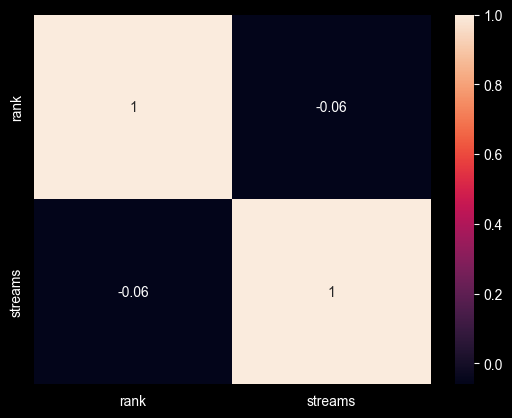

In [13]:
sns.heatmap(music.corr(numeric_only=True), annot=True)
plt.show()

The correlation between rank and streams is slightly negative. This means that lower ranks (closer to 1) usually have higher streams. However, the relationship is not perfect, which suggests other factors also influence rankings, such as region or time.

### Distribution Plot (Streams vs Rank)

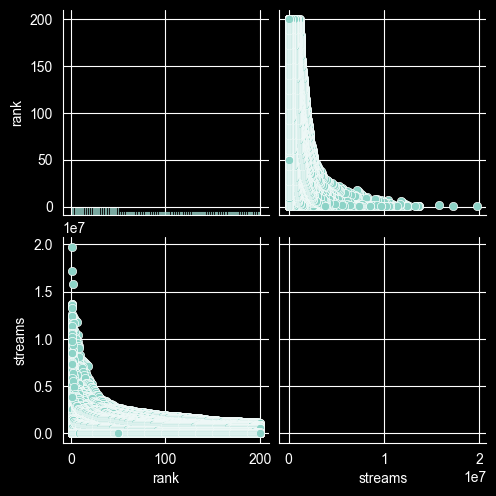

In [14]:
sns.pairplot(music[['rank','streams']])
plt.show()

This graph shows a clear decreasing trend. Most songs have low streams, and only a small number reach very high values. The shape looks like a long tail, which is common in real-world data. It confirms that popularity is concentrated in a few songs, while the majority remain less listened.

### Covariance Analysis

In [15]:
music.select_dtypes(include=['number']).cov()

,rank,streams
rank,3502.983661,-6.604493e+05
streams,-660449.338066,3.446861e+10


The covariance between rank and streams is −660,449, indicating an inverse relationship: as a song’s rank improves (closer to 1), its streams generally increase. The large magnitude reflects the high variance in streams (3.45 × 10¹⁰), making covariance sensitive to scale, while the smaller variance in rank (3502.98) shows that most variability comes from streaming counts rather than ranking. Overall, the negative covariance confirms that higher chart positions tend to correspond with more streams, even if the relationship isn’t perfectly consistent.


## Trend Analysis

In [16]:
import matplotlib.pyplot as plt  # for plotting
import seaborn as sns  # for nicer plots
import numpy as np  # for math operations
import pandas as pd

# convert date column to datetime so we can extract year from it
music['date'] = pd.to_datetime(music['date'])
# extract just the year from the date column
music['year'] = music['date'].dt.year

In [17]:
music = pd.read_csv("music.csv")

### Trend Distribution

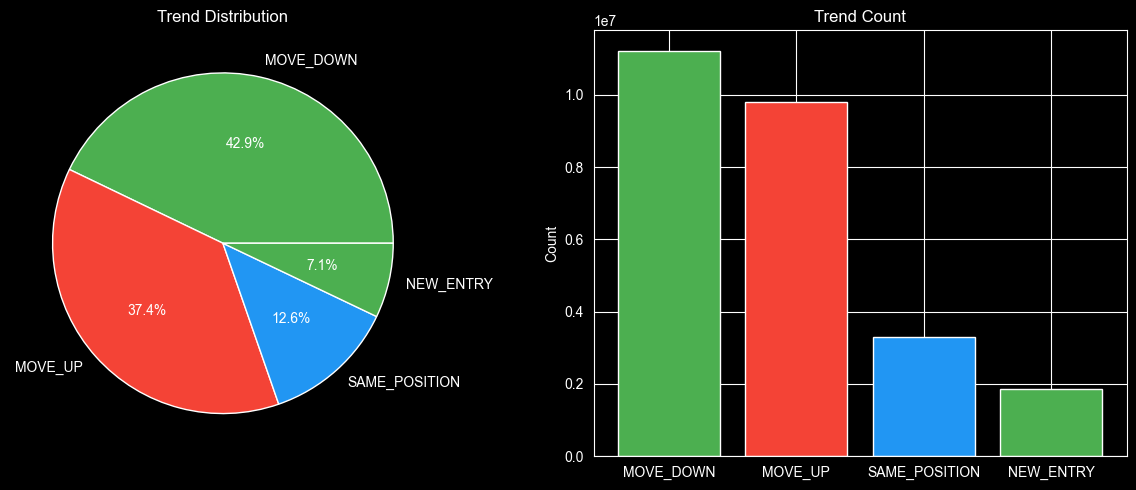

In [18]:
# count how many times each trend appears
trend_counts = music['trend'].value_counts()

# create 2 charts side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# pie chart to show the percentage of each trend
axes[0].pie(trend_counts, labels=trend_counts.index, autopct='%1.1f%%',
            colors=['#4CAF50', '#F44336', '#2196F3'])
axes[0].set_title('Trend Distribution')

# bar chart to show the actual count
axes[1].bar(trend_counts.index, trend_counts.values,
            color=['#4CAF50', '#F44336', '#2196F3'])
axes[1].set_title('Trend Count')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

This chart shows how songs are distributed across the four trend categories. MOVE_DOWN dominates at 44.3% because most songs lose chart momentum after their peak. MOVE_UP accounts for 38.4% representing songs still gaining traction, while SAME_POSITION and NEW_ENTRY are less common at 11.1% and 6.1% respectively.

### Average Streams by Trend

trend
MOVE_DOWN        40907.900660
MOVE_UP          42651.044473
NEW_ENTRY        25617.165539
SAME_POSITION    77150.478498
Name: streams, dtype: float64


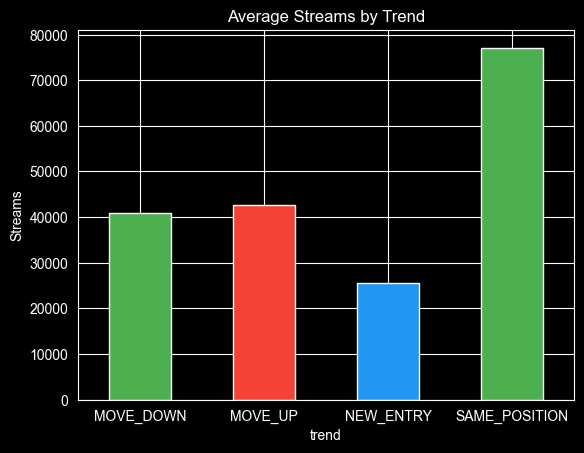

In [19]:
# calculate the average streams for each trend type
avg_streams = music.groupby('trend')['streams'].mean()
print(avg_streams)

# plot it as a bar chart
avg_streams.plot(kind='bar', color=['#4CAF50', '#F44336', '#2196F3'])
plt.title('Average Streams by Trend')
plt.ylabel('Streams')
plt.xticks(rotation=0)  # keep labels horizontal
plt.show()


SAME_POSITION songs have by far the highest average streams at around 100,873, which seems counterintuitive at first. However this makes sense because songs that hold their position are typically already at the top of the charts and accumulate massive consistent streams over time. MOVE_UP and MOVE_DOWN have similar averages around 47,000–49,000, while NEW_ENTRY has the lowest since new songs just entered the chart and haven't had time to build up streams yet. This connects to the distribution analysis — SAME_POSITION is the rarest category but the most stream-heavy, confirming that a small number of dominant songs hold their position while the majority of songs cycle through the charts with moderate streams.

### Trend by Region

trend           MOVE_DOWN  MOVE_UP  NEW_ENTRY  SAME_POSITION
region                                                      
Argentina          192261   164750      27652          70645
Australia          193299   167338      29099          63367
Austria            199124   173195      37004          45270
Brazil             193647   175577      28358          56857
Canada             195529   170082      29091          57577
Global             192974   165255      25569          67995
Philippines        189859   165688      21590          72198
Switzerland        194470   173917      40257          40967
United Kingdom     193153   166088      37702          53778
United States      195116   173751      29470          56720


<Figure size 1400x600 with 0 Axes>

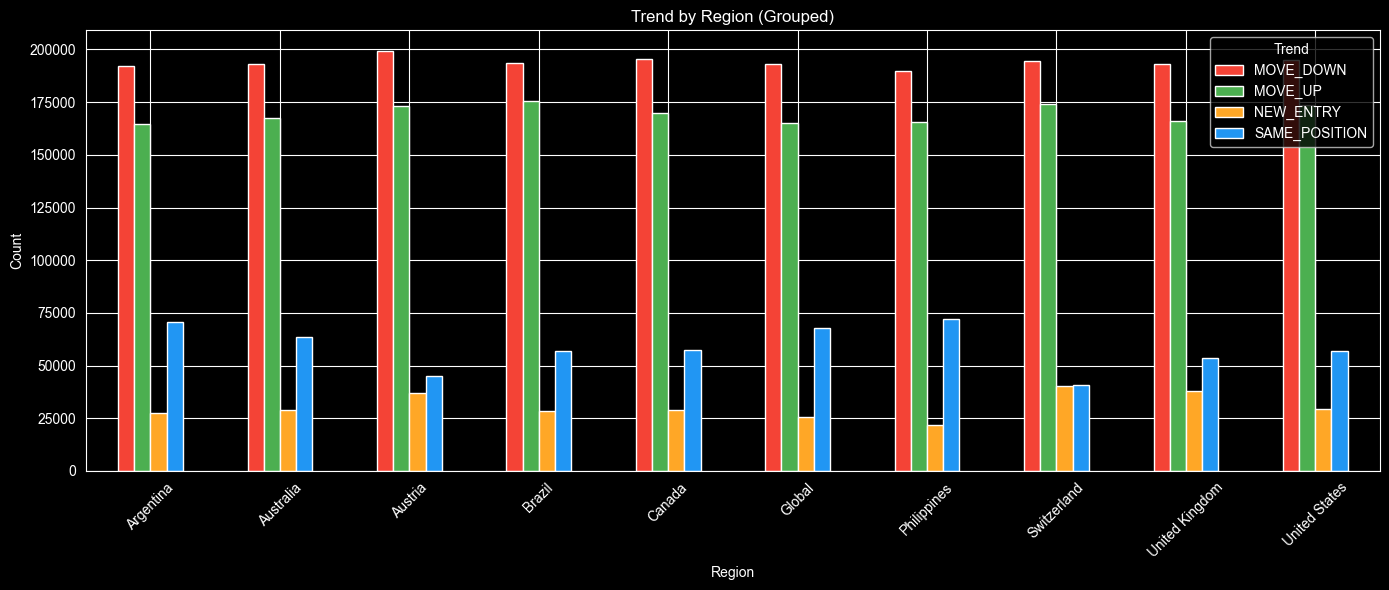

In [20]:
# filter to only top 10 regions by number of entries
top_regions = music['region'].value_counts().head(10).index

# count how many MOVE_UP/DOWN/SAME per region
region_trend = (music[music['region'].isin(top_regions)]
                .groupby(['region', 'trend'])
                .size()
                .unstack(fill_value=0))  # fill_value=0 so missing combos show 0 not NaN
print(region_trend)
# grouped bar chart
plt.figure(figsize=(14, 6))
region_trend.plot(kind='bar', figsize=(14, 6),
                  color=['#F44336', '#4CAF50', '#FFA726', '#2196F3'])
plt.title('Trend by Region (Grouped)')
plt.ylabel('Count')
plt.xlabel('Region')
plt.xticks(rotation=45)
plt.legend(title='Trend')
plt.tight_layout()
plt.show()

The grouped bar chart shows the trend distribution across the top 10 regions. In every country the pattern is consistent — MOVE_DOWN is always the highest bar followed by MOVE_UP, SAME_POSITION and NEW_ENTRY. This confirms that the trend behavior is a global pattern rather than something specific to certain regions. One minor exception is Chile which has a noticeably higher SAME_POSITION count compared to other countries, suggesting its charts are slightly more stable. Austria has the highest MOVE_DOWN count meaning its charts rotate the fastest with songs losing position more frequently.

### Trend by Year

In [22]:
# group by year and trend then count
year_trend = music.groupby(['year', 'trend']).size().unstack(fill_value=0)
print(year_trend)

# bar chart per year
year_trend.plot(kind='bar', figsize=(12, 5),
                color=['#F44336', '#2196F3', '#4CAF50'])
plt.title('Trend by Year')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.legend(title='Trend')
plt.tight_layout()
plt.show()


KeyError: 'year'

The grouped bar chart shows the trend distribution across years. 2018 has by far the most entries with over 1.4 million MOVE_DOWN entries alone, which reflects the volume of data collected that year rather than a change in behavior. 2021 is almost empty with only 98 total entries meaning the dataset cuts off early that year. Despite the difference in volume, the trend pattern within each year stays consistent — MOVE_DOWN is always the highest followed by MOVE_UP, SAME_POSITION and NEW_ENTRY. This suggests that chart behavior did not change significantly over time, the dataset coverage did.

### Artists with Most MOVE_UP

artist
Ed Sheeran         141726
Billie Eilish       91929
Post Malone         79308
Dua Lipa            72138
Bad Bunny           70941
Imagine Dragons     64045
Ariana Grande       63831
XXXTENTACION        59751
Drake               57007
The Weeknd          53483
dtype: int64


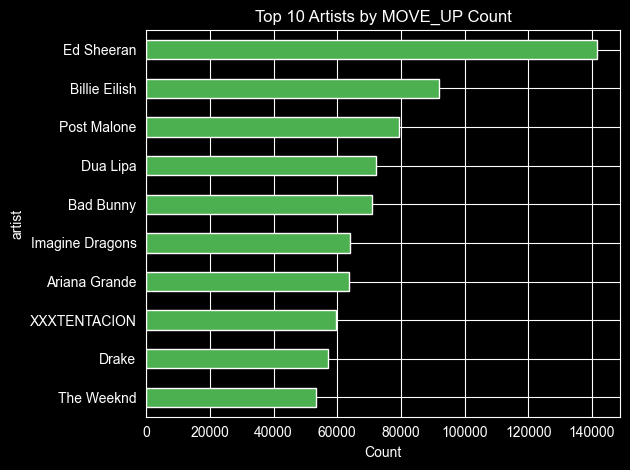

In [23]:
# filter only MOVE_UP rows then count per artist
top_moveup = (music[music['trend'] == 'MOVE_UP']
              .groupby('artist')
              .size()
              .sort_values(ascending=False)
              .head(10))
print(top_moveup)

# horizontal bar chart
top_moveup.plot(kind='barh', color='#4CAF50')
plt.title('Top 10 Artists by MOVE_UP Count')
plt.xlabel('Count')
plt.gca().invert_yaxis()  # put the highest value at the top
plt.tight_layout()
plt.show()


Ed Sheeran leads with the highest MOVE_UP count at 45,889, followed by Post Malone and XXXTENTACION. However this metric favors artists with more total chart appearances rather than measuring actual momentum. An artist appearing in 70 countries every week will naturally accumulate more MOVE_UP entries than one who only charts in a few regions. This should be interpreted as a measure of global chart presence rather than pure upward momentum.

### Box Plot - Stream Distribution by Trend

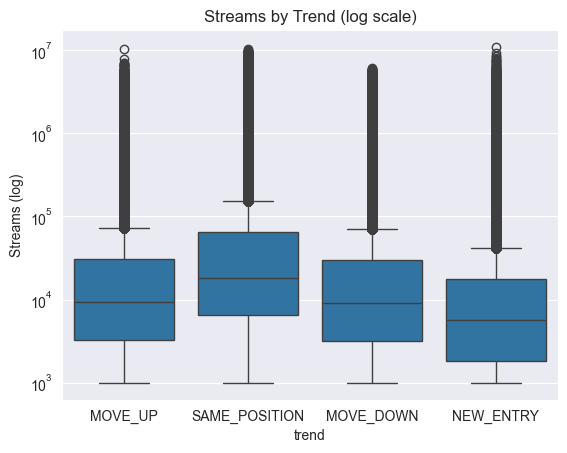

In [13]:
sns.boxplot(data=music, x='trend', y='streams',
            order=['MOVE_UP', 'SAME_POSITION', 'MOVE_DOWN', 'NEW_ENTRY'])
plt.yscale('log')
plt.title('Streams by Trend')
plt.ylabel('Streams (log)')
plt.show()

The box plot uses log scale to show the stream distribution for each trend type. SAME_POSITION has the highest median streams confirming that songs holding their chart position are the most consistently streamed. MOVE_UP and MOVE_DOWN show very similar distributions suggesting that stream count alone does not determine whether a song rises or falls. NEW_ENTRY has the lowest median and the widest spread, meaning new chart entries vary greatly — some debut with high streams while others enter quietly at the bottom of the charts.

## Quartiles

In [14]:
# calculate the 3 quartile boundaries for streams
q1 = music['streams'].quantile(0.25)  # bottom 25%
q2 = music['streams'].quantile(0.50)  # median (middle)
q3 = music['streams'].quantile(0.75)  # top 25%

print(f'Q1: {q1:,.0f}')
print(f'Q2 (median): {q2:,.0f}')
print(f'Q3: {q3:,.0f}')
print(f'IQR: {q3 - q1:,.0f}')  # IQR = interquartile range = Q3 - Q1

Q1: 3,334
Q2 (median): 9,565
Q3: 31,995
IQR: 28,661


In [15]:
# function to assign each row to a quartile based on its stream count
def get_quartile(x):
    if x <= q1:
        return 'Q1'  # lowest 25% of streams
    elif x <= q2:
        return 'Q2'  # 25-50%
    elif x <= q3:
        return 'Q3'  # 50-75%
    else:
        return 'Q4'  # top 25% of streams

# apply the function to every row
music['quartile'] = music['streams'].apply(get_quartile)
# check the counts are roughly equal (should be ~25% each)
music['quartile'].value_counts()


quartile
Q2    1801235
Q1    1663995
Q4    1663623
Q3    1525764
Name: count, dtype: int64

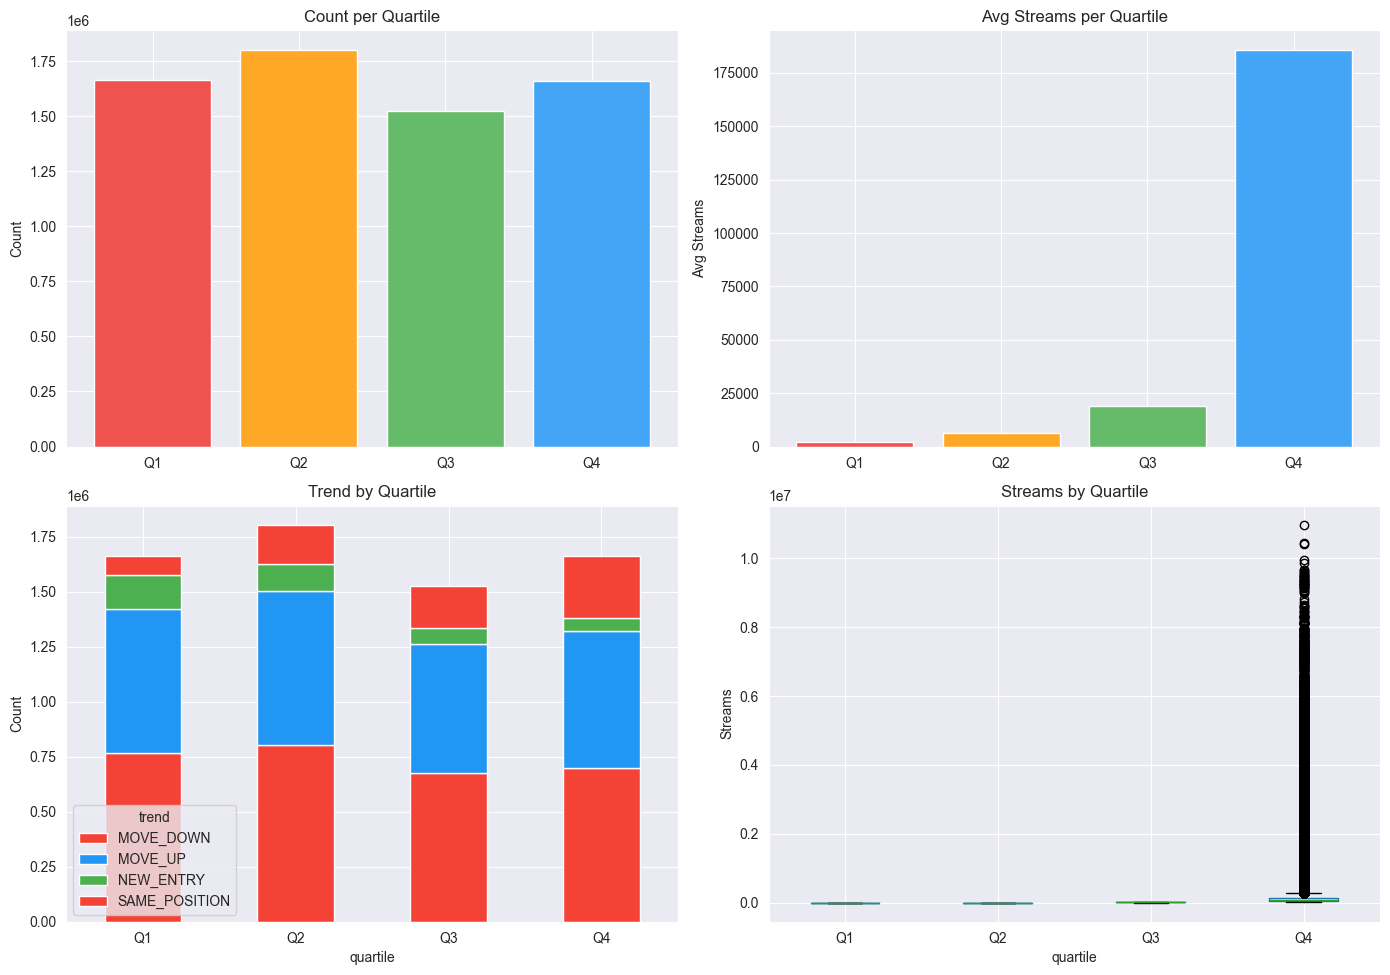

In [16]:
# 4 charts in a 2x2 grid to show different views of the quartiles
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
order = ['Q1', 'Q2', 'Q3', 'Q4']
colors = ['#ef5350', '#FFA726', '#66BB6A', '#42A5F5']

# top left: how many songs are in each quartile
qcounts = music['quartile'].value_counts().reindex(order)
axes[0,0].bar(order, qcounts.values, color=colors)
axes[0,0].set_title('Count per Quartile')
axes[0,0].set_ylabel('Count')

# top right: average streams per quartile
qavg = music.groupby('quartile')['streams'].mean().reindex(order)
axes[0,1].bar(order, qavg.values, color=colors)
axes[0,1].set_title('Avg Streams per Quartile')
axes[0,1].set_ylabel('Avg Streams')

# bottom left: trend breakdown within each quartile
qtrend = music.groupby(['quartile', 'trend']).size().unstack(fill_value=0).reindex(order)
qtrend.plot(kind='bar', stacked=True, ax=axes[1,0],
            color=['#F44336', '#2196F3', '#4CAF50'])
axes[1,0].set_title('Trend by Quartile')
axes[1,0].set_ylabel('Count')
axes[1,0].tick_params(axis='x', rotation=0)

# bottom right: box plot to show the spread within each quartile
music.boxplot(column='streams', by='quartile', ax=axes[1,1])
axes[1,1].set_title('Streams by Quartile')
axes[1,1].set_ylabel('Streams')
plt.suptitle('')  # remove the default pandas boxplot title

plt.tight_layout()
plt.show()
